# İş Akışı ve Hiperparametre Optimizasyonu

In [27]:
import pandas as pd
import seaborn as sns
import numpy as np

🏠 Ev fiyatları veri setini içe aktarın. Basitlik adına sadece sayısal özellikleri tutacağız

🎯 Hedefiniz en iyi KNN Regressor'ı yerleştirmek olacak. Özellikle, ev fiyatlarınız için en iyi tahminleri elde etmek üzere kaç tane "komşu" (<font color=blue>K</font>NN'deki <font color=blue>K</font>) göz önünde bulundurmalısınız?

In [28]:
# Load raw data
data = pd.read_csv('https://d32aokrjazspmn.cloudfront.net/materials/houses_train_raw.csv', index_col="Id")

# Only keep numerical columns and raws without NaN
data = data.select_dtypes(include=np.number).dropna()

data

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500


In [29]:
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

## 1. Eğitim/Test Ayrımı

❓ **Soru (Holdout)**❓

👇 `X_train`, `X_test`, `y_train` ve `y_test` oluşturmak için veri setini böl. Şunları kullan:
- `test_size=0.3`
- Sonuçlarınızı arkadaşınızla karşılaştırmak için `random_state=0`

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

## 2. Ölçeklendirme

⚖️ Ölçeklendirme KNN algoritması için her zaman kritik derecede önemlidir..

❓ **Soru (Ölçeklendirme)** ❓ 

* Eğitim setinizi ve test setinizi ölçeklendirin.
* Burada, basitçe `StandardScaler` uygulayalım ve özellik başına bir ölçekleyici seçerek zaman kaybetmeyelim. Gerçekten de, bu egzersizin amaçları şunlardır:
    * KNN'i gözden geçirmek
    * GridSearchCV'yi anlamak
    * RandomizedSearchCV'yi anlamak

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Temel KNN modeli

❓ **Soru (KNN için bir temel)** ❓

Sadece _en yakın komşuyu_ dikkate alan basit bir KNN regressor'ı çapraz doğrulayın (*cv = 5*) ve 5 kat üzerindeki ortalama skoru hesaplayın.

In [32]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_validate

knn = KNeighborsRegressor(n_neighbors=1)

cross_validate(knn, X_train_scaled, y_train, cv=5)["test_score"].mean()

0.5601542887874071

## 4. GridSearch

### 4.1. İlk GridSearch

❓ **Soru (GridSearch v1)**❓

En iyi KNN hiperparametresini `n_neighbors` bulmak için SKLearn `GridSearchCV` kullanalım.
- `n_neighbors` = [1,5,10,20,50] ile kaba taneli bir yaklaşım başlat
- Her parametreyi 5-kat çapraz doğrula
- `n_jobs` kullanarak performans sürenizi maksimize ettiğinizden emin olun

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# Instantiate model
model = KNeighborsRegressor()

# Hyperparameter Grid
param_grid = {"n_neighbors": [1, 5, 10, 20, 50]}

# Instantiate Grid Search
grid_search = GridSearchCV(model, param_grid, cv=5)

# Fit data to Grid Search
grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [1, 5, 10, 20, 50]})

❓ **Soru (en iyi parametreler)** ❓

GridSearch'e göre, optimal K değeri nedir?

In [34]:
best_k = grid_search.best_params_['n_neighbors']

❓ **Soru (puanlama)** ❓ Optimal K değerinin ürettiği en iyi skor nedir?

In [35]:
grid_search.best_score_

0.7596697382171873

In [36]:
best_model = grid_search.best_estimator_
best_model

KNeighborsRegressor(n_neighbors=10)

### 4.2. İkinci GridSearch

❓ **Soru (GridSearch V2)** ❓

Şimdi, en iyi $K$'nın nerede olduğu hakkında bir fikrimiz var, ancak denemediğimiz bazı değerler daha iyi bir performansla sonuçlanabilir.

* Önceki en iyi değerinizin çevresindeki $K$ için bazı değerleri deneyerek GridSearch'ü yeniden çalıştırın
* Bu rafine edilmiş GridSearch için `best_score` ve `best_k` nelerdir?

In [37]:
# Instantiate model
model = KNeighborsRegressor()

# Hyperparameter Grid
k_refined = {
    "n_neighbors": list(range(max(1, best_k - 3), best_k + 4))
}

# Instantiate Grid Search
grid_refined = GridSearchCV(
    model,
    k_refined,
    cv=5,
    n_jobs=-1
)

# Fit data to Grid Search
grid_refined.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [7, 8, 9, 10, 11, 12, 13]})

In [38]:
print(grid_refined.best_params_["n_neighbors"])
print(grid_refined.best_score_)

13
0.7628734645391733


In [39]:
best_k = grid_refined.best_params_["n_neighbors"]
best_score = grid_refined.best_score_

***🧪 Kodunuzu test edin***

In [40]:
from nbresult import ChallengeResult
result = ChallengeResult('knn',
                         best_k=best_k,
                         best_score=best_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/ilos/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/ilos/code/D16D5-S-data-workflow/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_knn.py::TestKnn::test_best_k PASSED                                 [ 50%]
test_knn.py::TestKnn::test_best_score PASSED                             [100%]

============================== 2 passed in 0.10s ===============================


💯 You can commit your code:

git add tests/knn.pickle

git commit -m 'Completed knn step'

git push origin master



### 4.3. Görsel kontrol (manuel GridSearch)

☝️ Bu problem aslında manuel olarak GridSearch yapmak için yeterince basittir.

❓ **Soru(Manuel GridSearch)** ❓

- $K$'nın $1$'den $50$'ye kadar tüm değerleri üzerinde manuel olarak döngü yapın ve her modelin çapraz doğrulanmış skorlarının ortalamasını bir listede saklayın.
- `Dirsek Yöntemi` kullanarak en iyi $K$'yı görsel olarak bulmak için skorları $K$'nın bir fonksiyonu olarak çizin

In [41]:
from sklearn.model_selection import cross_val_score

scores = []

for k in range(1, 51):
    knn = KNeighborsRegressor(n_neighbors=k)
    score = cross_val_score(knn, X_train_scaled, y_train, cv=5).mean()
    scores.append(score)

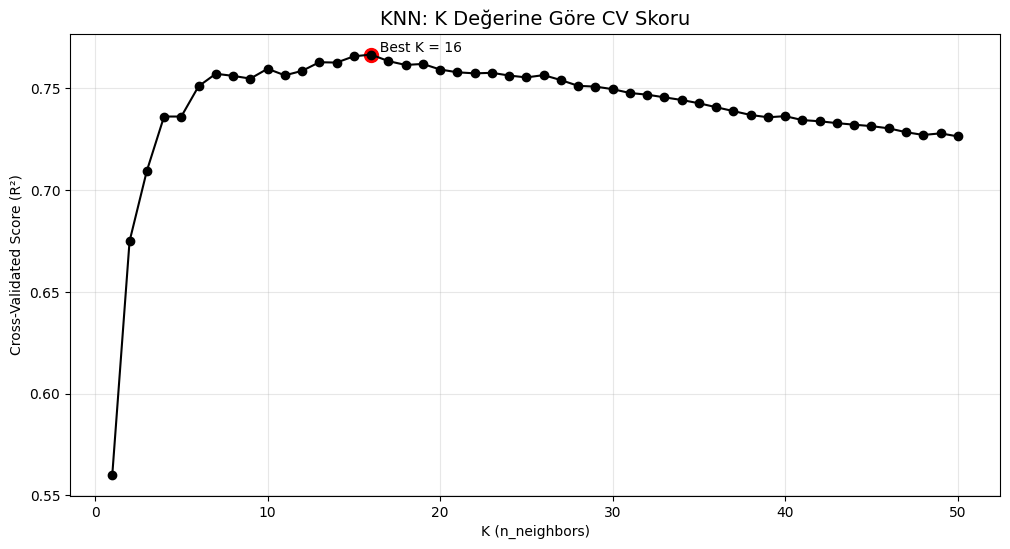

In [42]:
import matplotlib.pyplot as plt

k_values = range(1, 51)

plt.figure(figsize=(12, 6))

plt.plot(k_values, scores, marker='o', linestyle='-', color='black')

plt.title("KNN: K Değerine Göre CV Skoru", fontsize=14)
plt.xlabel("K (n_neighbors)")
plt.ylabel("Cross-Validated Score (R²)")

# en iyi K
best_k = k_values[scores.index(max(scores))]

# en iyi nokta
plt.scatter(best_k, max(scores), color='red', s=100)
plt.text(best_k, max(scores), f"  Best K = {best_k}", verticalalignment='bottom')

plt.grid(True, alpha=0.3)

plt.show()

❓GridSearchCV'yi böyle bir manuel döngüden daha iyi bir seçenek yapan şeyi tahmin edebilir misiniz?

<details>
    <summary>Cevap</summary>

- Sklearn'ın `n_jobs=-1` seçeneği aramayı paralelleştirmenize izin verir, tüm CPU çekirdeklerinizi kullanır
- Birlikte optimize edilecek birden fazla hiperparametreniz olsaydı ne olurdu?
</details>

## 5. Birden çok parametre ile GridSearch

👩🏻‍🏫 KNNRegressor, `p` hiperparametresi aracılığıyla çeşitli _mesafe metrikleri_ destekler

📚 [sklearn.neighbors.KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)

❓ **Soru (birden çok parametreyi ayarlama)** ❓

* En iyi $K$ ve $p$'yi aynı anda aramak için GridSearchCV kullanın.
    * $K = [1, 5, 10, 20, 50]$ ve $p = [1, 2, 3]$ için tüm kombinasyonları deneyin.

In [52]:
knn = KNeighborsRegressor()

param_grid = {
    "n_neighbors": [1, 5, 10, 20, 50],
    "p": [1, 2, 3]
}

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    n_jobs=-1,
)

grid.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 5, 10, 20, 50], 'p': [1, 2, 3]})

❓ **Soru (alt model sayısı)**❓

Toplamda kaç alt model eğittiniz?

<details>
    <summary>İpucu</summary>

15'ten çok daha fazla. İki kez düşün :)
    <details>
    <summary>Cevap</summary>

CV=5 nedeniyle 75 model
</details>

In [53]:
# 15 x 5 = 75 farklı model eğitildi

❓ **Soru (modeli birden çok parametre ile ayarladıktan sonra en iyi parametreler ve en iyi skor)**❓

*En iyi parametreler* ve *en iyi skor* nedir?

In [55]:
grid.best_params_

{'n_neighbors': 10, 'p': 1}

In [56]:
grid.best_score_

0.7969255879201194

## 6. Rastgele Arama

Şimdi bir RandomizedSearch'ün aynı sayıda model yerleştirilerek daha iyi bir kombinasyon bulup bulamayacağını görelim.

❓ **Soru (RandomizedSearchCV)** ❓

`RandomizedSearchCV` kullanarak
- $K$'yı uniform `scipy.stats.randint(1,50)` ([döküman](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html)) dağılımından rastgele örnekle
- $p$'yi $[1,2,3]$ listesinden örnekle
- Önceki GridSearchCV'nizdeki ile tam olarak aynı sayıda model yerleştirmek için doğru `n_iter` ve `cv` sayılarını kullanın.

In [61]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

knn = KNeighborsRegressor()

param_dist = {
    "n_neighbors": randint(1, 50),
    "p": [1, 2, 3]
}

random_search = RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    n_jobs=-1,
    random_state=0
)

random_search.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsRegressor(), n_iter=15, n_jobs=-1,
                   param_distributions={'n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x145a178f0>,
                                        'p': [1, 2, 3]},
                   random_state=0)

In [62]:
random_search.best_params_

{'n_neighbors': 10, 'p': 1}

In [63]:
random_search.best_score_

0.7969255879201194

## 7. Genelleme

❓ **Soru (modelinizi bir kez daha ince ayarlama)**❓

- İsterseniz RandomsearchCV'nizi rafine edin
- En iyi modelinizi seçin

In [66]:
best_model = random_search.best_estimator_

Şimdi `cv_results`'ınızı bir `DataFrame` olarak görüntülemeye çalışın, bu CV'nin içinde neler olup bittiğini görselleştirmenize yardımcı olacak! 😉

In [67]:
pd.DataFrame(random_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_p,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004890,0.003062,0.005849,0.000929,45,2,"{'n_neighbors': 45, 'p': 2}",0.732582,0.784430,0.684748,0.759886,0.695648,0.731459,0.037629,11
1,0.001346,0.000973,0.001654,0.000491,1,2,"{'n_neighbors': 1, 'p': 2}",0.542701,0.684186,0.250163,0.778582,0.545139,0.560154,0.178729,15
2,0.001354,0.000731,0.003037,0.001923,20,2,"{'n_neighbors': 20, 'p': 2}",0.735777,0.808371,0.708587,0.815256,0.728469,0.759292,0.043851,7
3,0.000655,0.000240,0.048044,0.003048,37,3,"{'n_neighbors': 37, 'p': 3}",0.706299,0.773799,0.657572,0.750440,0.663685,0.710359,0.046070,12
4,0.001034,0.000541,0.007114,0.000689,25,1,"{'n_neighbors': 25, 'p': 1}",0.769800,0.807158,0.723375,0.818164,0.760461,0.775792,0.034052,5
5,0.000881,0.000280,0.043950,0.002881,13,3,"{'n_neighbors': 13, 'p': 3}",0.720849,0.775248,0.700543,0.794905,0.691842,0.736677,0.041096,10
6,0.001139,0.001317,0.041728,0.007699,2,3,"{'n_neighbors': 2, 'p': 3}",0.631907,0.700492,0.638001,0.806689,0.535899,0.662598,0.089216,14
7,0.000518,0.000238,0.038390,0.006406,40,3,"{'n_neighbors': 40, 'p': 3}",0.703138,0.766186,0.645409,0.740804,0.658910,0.702890,0.046222,13
8,0.000499,0.000272,0.001784,0.000476,25,2,"{'n_neighbors': 25, 'p': 2}",0.739938,0.812000,0.699433,0.800460,0.725192,0.755405,0.043630,8
9,0.000537,0.000350,0.002209,0.001124,38,2,"{'n_neighbors': 38, 'p': 2}",0.727468,0.790148,0.685940,0.775245,0.705862,0.736933,0.039887,9


❓ **Soru ("En iyi" modelin değerlendirmesi)** ❓

* "En iyi parametrelerle" modelimizin **görülmemiş** test seti `X_test` üzerindeki performansını keşfetme zamanı geldi.
    * Test seti için r2 skorunu hesaplayın ve `r2_test` olarak kaydedin.

In [68]:
from sklearn.metrics import r2_score

r2_test = r2_score(y_test, best_model.predict(scaler.transform(X_test)))
r2_test

0.7731141456725311

❓ **Soru (Bir adım geri çekilme)** ❓

Optimize edilmiş modelin iyi genelleme yaptığını düşünür müsünüz?

<details><summary>Cevap</summary>

Test skoru eğitim seti ile biraz azalabilir. Muhtemelen %5'ten fazla değil. Bunun nedeni şunlar olabilir:
- Temsili olmayan bir eğitim/test bölünmesi
- Model ayarlama aşamasında aşırı öğrenmeye yol açan çok küçük bir çapraz doğrulama sayısı. Ne kadar çok çapraz doğrulama yaparsanız, bulgularınız o kadar güçlü genelleşir - ancak veri setiniz çok küçükse cv'yi çok fazla artıramazsınız çünkü her katmanda temsili olmak için yeterli gözlemi tutamazsınız.
- Veri setimiz çok küçük ve hiperparametre optimizasyonumuz bu nedenle eğitim/test bölünmemize son derece bağımlı (ve aşırı uyum gösteriyor). Veri setinizin denediğiniz toplam hiperparametre kombinasyonu sayısından çok daha büyük olduğundan her zaman emin olun!
    
</details>

***🧪 Kodunuzu test edin***

In [69]:
from nbresult import ChallengeResult
result = ChallengeResult('r2', 
                         r2_test=r2_test)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/ilos/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/ilos/code/D16D5-S-data-workflow/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_r2.py::TestR2::test_r2 PASSED                                       [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/r2.pickle

git commit -m 'Completed r2 step'

git push origin master



🏁 Tebrikler! Artık GridSearchCV veya RandomizedSearchCV kullanarak bir modeli nasıl ince ayarlayacağınızı biliyorsunuz

💾 Notebook'unuzu `git add/commit/push` yapmayı unutmayın...

🚀 ... ve bir sonraki meydan okumaya geçin!